<img src="https://media.giphy.com/media/FSzLVme5Y3n3LMOiqP/giphy.gif" width="250" height="250"/>


Remember the rules of ~Fight~ Code Club:
1. ALWAYS DOCUMENT
2. Cite resources that you use (paste links)
3. Include the names people who you worked with
4. Be neat and organized

## Questions

With your own data that you collected:
1. Create 2 graphs between two variables. Be sure to include the title, labels of both axis. Include a legend if necessary. Be sure that nothing overlaps in the graph (words or legends, etc). 

2. Write 1-2 sentences that describe the main information presented and a conclusion that you could draw from that graph. 

3. Display the graphs side by side in one figure. 

4. Do a third graph that is not a line graph or bar chart (with proper labels and titles). Make sure this third graph displays different information than presented in step 1.


In [1]:
#from assignment 2: getting the data loaded in :
import requests
import pandas as pd

#Labeling API url

url = "https://api.census.gov/data/2022/acs/acs5"


#API Key, Columns/Variables of Interest, By county
url1 = {
    "get": "NAME,B08303_001E,B08303_012E,B08303_013E,B15003_001E,B15003_022E,B19013_001E",
    "for": "county:*",
    "key": "62e7098927e44aacb2ec1516548c851363a0635f"
}
print(url1)

{'get': 'NAME,B08303_001E,B08303_012E,B08303_013E,B15003_001E,B15003_022E,B19013_001E', 'for': 'county:*', 'key': '62e7098927e44aacb2ec1516548c851363a0635f'}


In [2]:
response = requests.get(url, params=url1)

data = response.json()

#Creating the DataFrame
df = pd.DataFrame(data[1:], columns=data[0])

# Converting to numerical form
cols = df.columns[1:-2]
df[cols] = df[cols].apply(pd.to_numeric)

In [20]:
# creating the variable for those who have long commute times: "Workers commuting 60–89 minutes" + "Workers commuting 90+ minutes" / Total workers

df["long_commute"] = (
    df["B08303_012E"] + df["B08303_013E"]
) / df["B08303_001E"]

# percentage of adults with college degrees: "Number of people with a Bachelor’s degree" / Total population (25+ years old)
df["college_rate"] = df["B15003_022E"] / df["B15003_001E"]


#creating an index of economic mobility - college rate * median income 
df["mobility_index"] = df["college_rate"] * df["B19013_001E"]

df.columns

Index(['NAME', 'B08303_001E', 'B08303_012E', 'B08303_013E', 'B15003_001E',
       'B15003_022E', 'B19013_001E', 'state', 'county', 'long_commute',
       'college_rate', 'mobility_index'],
      dtype='object')

In [14]:
#Created Organized Dataset
data = df[["NAME","state", "long_commute", "college_rate", "mobility_index","B19013_001E"]]
data=data.rename(columns={'B19013_001E':'median income'})

data

,NAME,state,long_commute,college_rate,mobility_index,median income
0,"Autauga County, Alabama",01,0.072026,0.167363,11433.430128,68315
1,"Baldwin County, Alabama",01,0.079995,0.200417,14237.402773,71039
2,"Barbour County, Alabama",01,0.104908,0.066025,2622.003055,39712
3,"Bibb County, Alabama",01,0.097382,0.065746,3331.268006,50669
4,"Blount County, Alabama",01,0.175782,0.094078,5403.866036,57440
...,...,...,...,...,...,...
3217,"Vega Baja Municipio, Puerto Rico",72,0.094379,0.191654,4542.399267,23701
3218,"Vieques Municipio, Puerto Rico",72,0.000000,0.067475,1151.266744,17062
3219,"Villalba Municipio, Puerto Rico",72,0.122248,0.176550,3965.492370,22461
3220,"Yabucoa Municipio, Puerto Rico",72,0.114061,0.149398,2983.770814,19972


In [19]:
##ASSIGNMENT 3 BEGIN:
#Importing matplotlib
import matplotlib.pyplot as plt
import seaborn as sns 

#creating commute burden groups for simplicity:
#source- https://www.geeksforgeeks.org/python/how-to-use-pandas-cut-and-qcut/ 
data["commute_group"] = pd.qcut(data["long_commute"],q=4,labels=["Lowest Commute", "Lower-Middle", "Upper-Middle", "Highest Commute"])

,NAME,state,long_commute,college_rate,mobility_index,median income,commute_group
0,"Autauga County, Alabama",01,0.072026,0.167363,11433.430128,68315,Upper-Middle
1,"Baldwin County, Alabama",01,0.079995,0.200417,14237.402773,71039,Upper-Middle
2,"Barbour County, Alabama",01,0.104908,0.066025,2622.003055,39712,Upper-Middle
3,"Bibb County, Alabama",01,0.097382,0.065746,3331.268006,50669,Upper-Middle
4,"Blount County, Alabama",01,0.175782,0.094078,5403.866036,57440,Highest Commute
...,...,...,...,...,...,...,...
3217,"Vega Baja Municipio, Puerto Rico",72,0.094379,0.191654,4542.399267,23701,Upper-Middle
3218,"Vieques Municipio, Puerto Rico",72,0.000000,0.067475,1151.266744,17062,Lowest Commute
3219,"Villalba Municipio, Puerto Rico",72,0.122248,0.176550,3965.492370,22461,Highest Commute
3220,"Yabucoa Municipio, Puerto Rico",72,0.114061,0.149398,2983.770814,19972,Highest Commute


In [22]:
#CREATING BAR CHARTS: GROUPING AVERAGES FOR VARIABLES:
averages = data.groupby("commute_group", observed=False).agg({"mobility_index": "mean", "median income": "mean"}).reset_index()

averages

,commute_group,mobility_index,median income
0,Lowest Commute,11829.776659,64342.313896
1,Lower-Middle,10160.551226,62456.924224
2,Upper-Middle,9215.901767,60771.535404
3,Highest Commute,9376.821542,-765472.256824


In [26]:
#finding the problem --> chat helped me
data[data["median income"] < 0][["NAME", "state", "median income", "long_commute", "commute_group"]]
data.loc[data["median income"] < 0, "median income"] = pd.NA
data.loc[data["median income"].isna(), "mobility_index"] = pd.NA

In [28]:
#trying averages again:
averages = data.groupby("commute_group", observed=False).agg({"mobility_index": "mean", "median income": "mean"}).reset_index()
averages

,commute_group,mobility_index,median income
0,Lowest Commute,11829.776659,64342.313896
1,Lower-Middle,10160.551226,62456.924224
2,Upper-Middle,9215.901767,60771.535404
3,Highest Commute,9388.469768,61734.195031


Text(0, 0.5, 'Mobility Index')

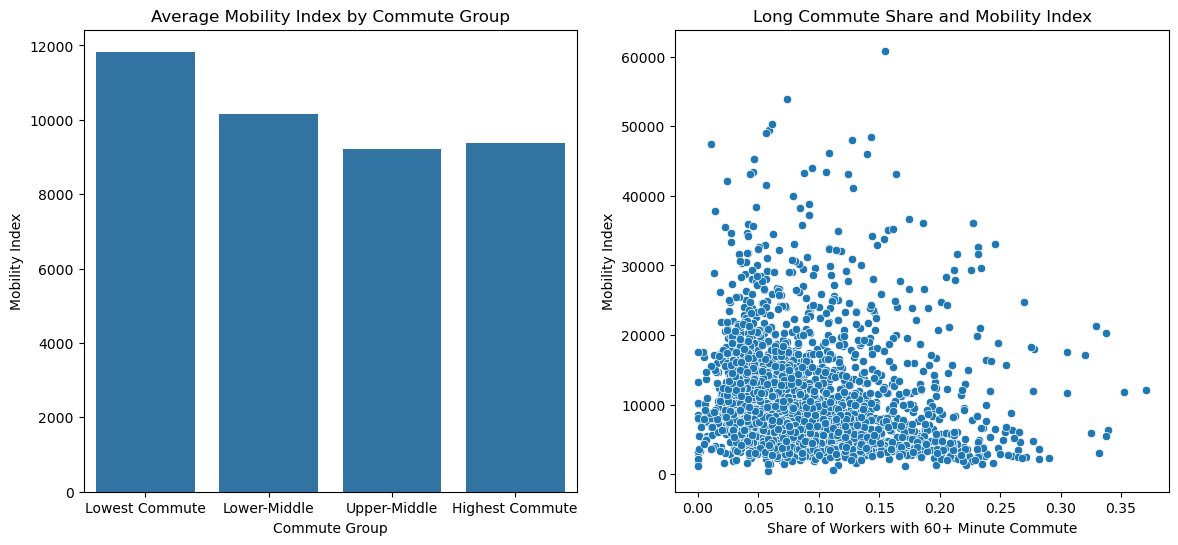

In [51]:
#creating size:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#bar graph creation :
graph1=sns.barplot(data=averages, x='commute_group',y='mobility_index',ax=axes[0])
#labeling: 
graph1.set_title("Average Mobility Index by Commute Group")
graph1.set_xlabel('Commute Group')
graph1.set_ylabel('Mobility Index')

#graph 2: comparing the long commute share with mobility index in scatterplot form
graph2 = sns.scatterplot(data=data, x='long_commute', y='mobility_index',ax=axes[1])
graph2.set_title("Long Commute Share and Mobility Index")
graph2.set_xlabel("Share of Workers with 60+ Minute Commute")
graph2.set_ylabel("Mobility Index")

In [ ]:
#DESCRIPTION FOR THE TWO CHARTS ABOVE:
#The bar chart on the left displays that those who fall into the lowest commute group (counties with the lowest share of 60+ minute commutes) have the highest mobility index (calculated by the college rate * medan income)
#The scatterplot on the right also suggests a negative relationship between mobility index and the share of workers with 60+ commutes, indicating that those with longer commute times typically have lower economic mobility.





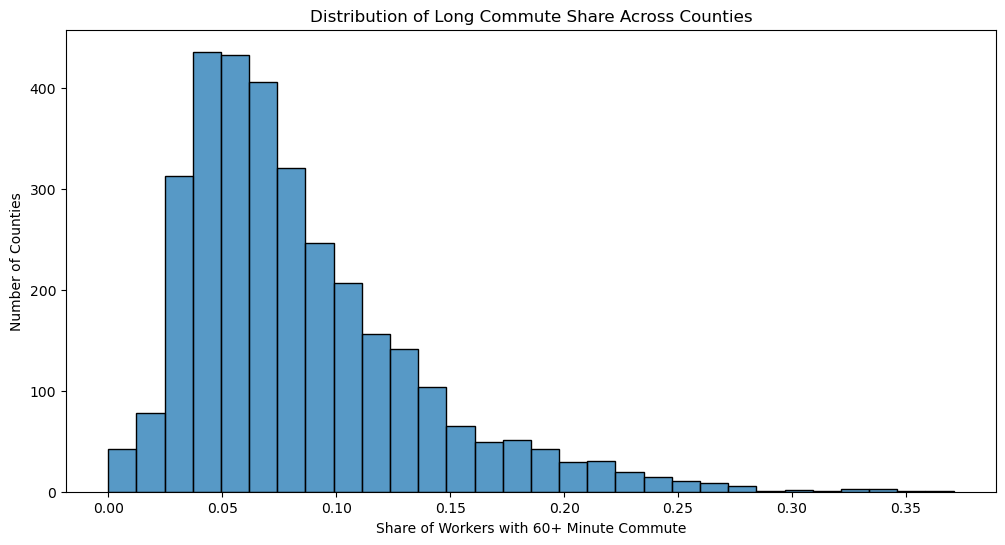

In [48]:
#GRAPH NUMBER 3 - HISTOGRAM
#source- https://seaborn.pydata.org/generated/seaborn.histplot.html
#creating size
plt.figure(figsize=(12, 6))

graph3 = sns.histplot(data=data, x="long_commute", bins=30)

graph3.set_title("Distribution of Long Commute Share Across Counties")
graph3.set_xlabel("Share of Workers with 60+ Minute Commute")
graph3.set_ylabel("Number of Counties")

plt.show()

In [ ]:
#DESCRIPTION: The histogram adds important context to this study; it's a visual aid allowing us to see the share of workers with 60+ min commutes in respect to the number of counties.







prof k : you need to document your code more! be sure to talk about what's in the mobility index; I would log it. you could do a country map that is shaded by strength of length of commute - that would be very interesting!  use shapefiles

grade: 95
